In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

In [2]:
results = pd.read_csv("member3_day1_w4results.csv")

y_true = results["Actual"].values
y_proba = results["Failure Probability"].values

print("Dataset loaded successfully")
print("Shape:", results.shape)

Dataset loaded successfully
Shape: (2000, 4)


In [3]:
thresholds = np.arange(0.3, 0.85, 0.1)
print("Thresholds:", thresholds)

Thresholds: [0.3 0.4 0.5 0.6 0.7 0.8]


In [4]:
def evaluate_threshold(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return tn, fp, fn, tp, precision, recall, f1

In [5]:
records = []

for t in thresholds:
    tn, fp, fn, tp, precision, recall, f1 = evaluate_threshold(y_true, y_proba, t)

    records.append({
        "Threshold": t,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

df_results = pd.DataFrame(records)
df_results

,Threshold,TN,FP,FN,TP,Precision,Recall,F1
0,0.3,1773,159,1,67,0.296460,0.985294,0.455782
1,0.4,1833,99,1,67,0.403614,0.985294,0.572650
2,0.5,1865,67,2,66,0.496241,0.970588,0.656716
3,0.6,1894,38,2,66,0.634615,0.970588,0.767442
4,0.7,1909,23,3,65,0.738636,0.955882,0.833333
5,0.8,1926,6,3,65,0.915493,0.955882,0.935252


In [6]:
best_row = df_results.loc[df_results["F1"].idxmax()]

print("BEST THRESHOLD (F1 OPTIMIZED)")

print(best_row)

BEST THRESHOLD (F1 OPTIMIZED)
Threshold       0.800000
TN           1926.000000
FP              6.000000
FN              3.000000
TP             65.000000
Precision       0.915493
Recall          0.955882
F1              0.935252
Name: 5, dtype: float64


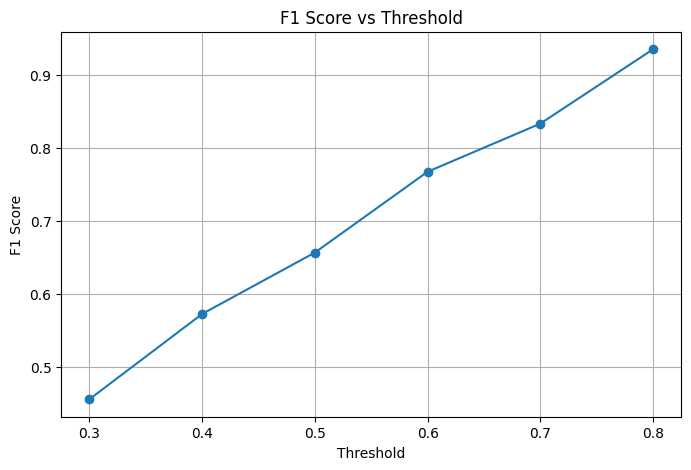

In [7]:
plt.figure(figsize=(8,5))
plt.plot(df_results["Threshold"], df_results["F1"], marker="o")

plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.grid()
plt.show()

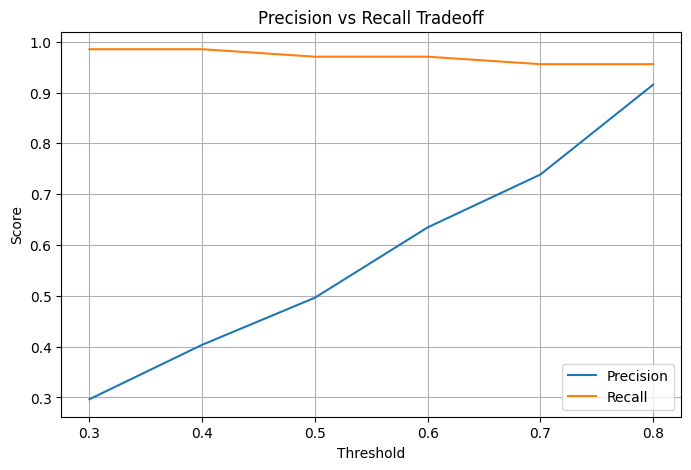

In [8]:
plt.figure(figsize=(8,5))

plt.plot(df_results["Threshold"], df_results["Precision"], label="Precision")
plt.plot(df_results["Threshold"], df_results["Recall"], label="Recall")

plt.title("Precision vs Recall Tradeoff")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

In [9]:
def plot_conf_matrix(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion Matrix (Threshold={threshold})")
    plt.colorbar()

    labels = ["No Failure", "Failure"]
    plt.xticks([0,1], labels)
    plt.yticks([0,1], labels)

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

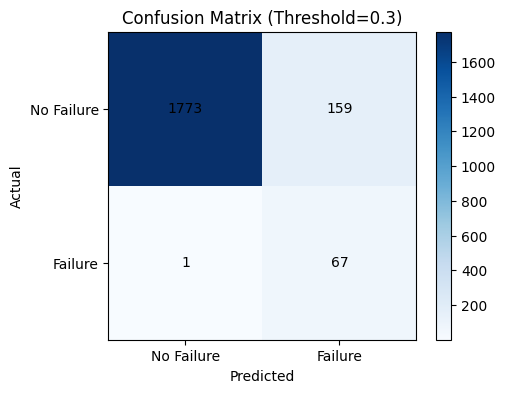

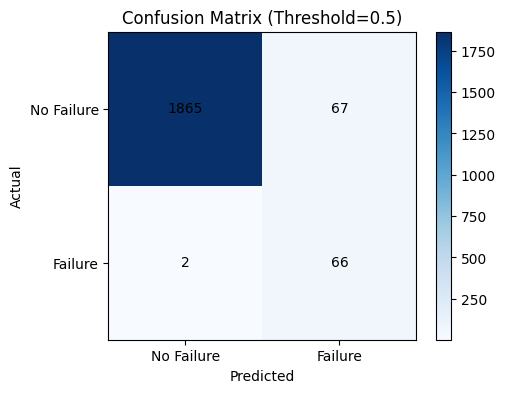

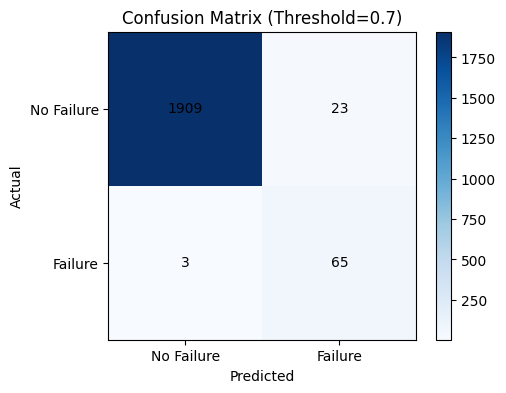

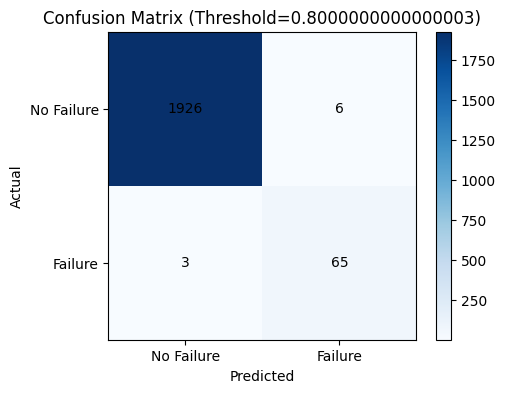

In [10]:
key_thresholds = [0.3, 0.5, 0.7, best_row["Threshold"]]

for t in key_thresholds:
    plot_conf_matrix(y_true, y_proba, t)

In [12]:

print("WEEK 4 DAY 3 - FINAL ANALYSIS REPORT")

print(f"Best Threshold: {best_row['Threshold']:.2f}")
print(f"Best F1 Score: {best_row['F1']:.3f}")

print("\nBusiness Interpretation:")
print("- Lower threshold → higher recall (safer system)")
print("- Higher threshold → fewer false alarms (cost saving)")
print("- Optimal threshold balances safety + cost")

print("\nConclusion:")
print("Threshold tuning significantly improves decision quality over default 0.5 cutoff.")
print("Final model is ready for deployment decision layer.")


WEEK 4 DAY 3 - FINAL ANALYSIS REPORT
Best Threshold: 0.80
Best F1 Score: 0.935

Business Interpretation:
- Lower threshold → higher recall (safer system)
- Higher threshold → fewer false alarms (cost saving)
- Optimal threshold balances safety + cost

Conclusion:
Threshold tuning significantly improves decision quality over default 0.5 cutoff.
Final model is ready for deployment decision layer.
